In [3]:
data.head(30)

,location_id,time,temperature_2m,relative_humidity_2m (%),wind_speed_10m (km/h),precipitation (mm),is_day,wind_speed_100m (km/h),wind_gusts_10m (km/h),wind_direction_100m,wind_direction_10m,cloud_cover (%),vapour_pressure_deficit (kPa)
0,0,2024-01-01T00:00,7.7,77,30.6,0.0,0,48.2,51.8,246,243,90,0.25
1,0,2024-01-01T01:00,7.6,77,29.5,0.0,0,47.4,50.8,249,246,60,0.24
2,0,2024-01-01T02:00,7.3,78,29.0,0.0,0,47.0,49.3,248,245,22,0.22
3,0,2024-01-01T03:00,7.0,80,26.8,0.0,0,44.1,48.2,251,248,33,0.20
4,0,2024-01-01T04:00,6.9,80,26.0,0.0,0,42.7,44.6,254,251,46,0.20
5,0,2024-01-01T05:00,6.8,79,26.2,0.0,0,43.3,43.6,255,252,32,0.20
6,0,2024-01-01T06:00,6.8,75,26.0,0.0,0,43.3,44.6,259,256,10,0.24
7,0,2024-01-01T07:00,6.4,74,24.9,0.0,0,41.8,43.2,259,256,93,0.25
8,0,2024-01-01T08:00,6.2,71,22.9,0.0,0,39.4,41.0,261,257,98,0.27
9,0,2024-01-01T09:00,5.8,71,19.6,0.0,0,35.5,37.8,260,256,100,0.27


In [3]:
import pandas as pd
import numpy as np

In [4]:
data = pd.read_csv("Weather-2020-2025.csv")

In [5]:
data = data.dropna()

In [6]:
daytime_data = data[data['is_day'] == 1]

#daytime temperature averages
daytime_data.groupby("location_id")["temperature_2m"].mean()


location_id
0    14.285160
1    12.855252
2    19.595864
Name: temperature_2m, dtype: float64

In [7]:
nighttime_data = data[data['is_day'] == 0]

#daytime temperature averages
nighttime_data.groupby("location_id")["temperature_2m"].mean()

location_id
0     9.741029
1     9.517392
2    15.247273
Name: temperature_2m, dtype: float64

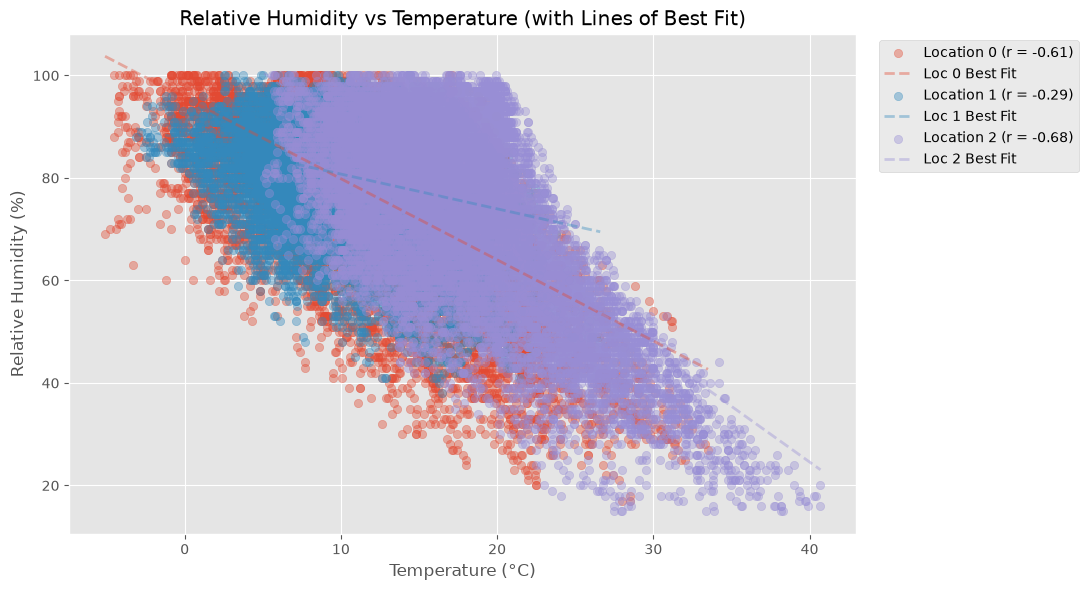

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Optional: set a clean background style for your presentation
plt.style.use('ggplot')

# Create one large figure for all three locations
plt.figure(figsize=(11, 6))

# Loop through each unique location ID in your dataset automatically
for loc_id in data['location_id'].unique():
    
    # 1. Filter the data for the current location (just like your Lisbon example)
    loc_df = data[data["location_id"] == loc_id].copy()
    
    # 2. Calculate the specific correlation value between Temp and Humidity
    corr_val = loc_df["temperature_2m"].corr(loc_df["relative_humidity_2m (%)"])
    
    # 3. Plot the scatter points 
    # We include the correlation score (r) directly in the label so it prints in the legend!
    scatter = plt.scatter(
        loc_df["temperature_2m"], 
        loc_df["relative_humidity_2m (%)"], 
        alpha=0.4, 
        label=f"Location {loc_id} (r = {corr_val:.2f})"
    )
    
    # Get the color of the scatter dots so the line matches perfectly
    line_color = scatter.get_facecolor()[0] 
    
    # 4. Plot the line of best fit using your exact polyfit template logic
    x = np.unique(loc_df["temperature_2m"])
    fit_function = np.poly1d(np.polyfit(loc_df["temperature_2m"], loc_df["relative_humidity_2m (%)"], 1))
    y = fit_function(x)
    
    plt.plot(x, y, label=f"Loc {loc_id} Best Fit", color=line_color, linewidth=2, linestyle="--")

# 5. Final touches to label your axes and clean up the chart
plt.title("Relative Humidity vs Temperature (with Lines of Best Fit)")
plt.xlabel("Temperature (°C)")
plt.ylabel("Relative Humidity (%)")

# Places the legend slightly outside the chart so it doesn't block any data points
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()

plt.show()

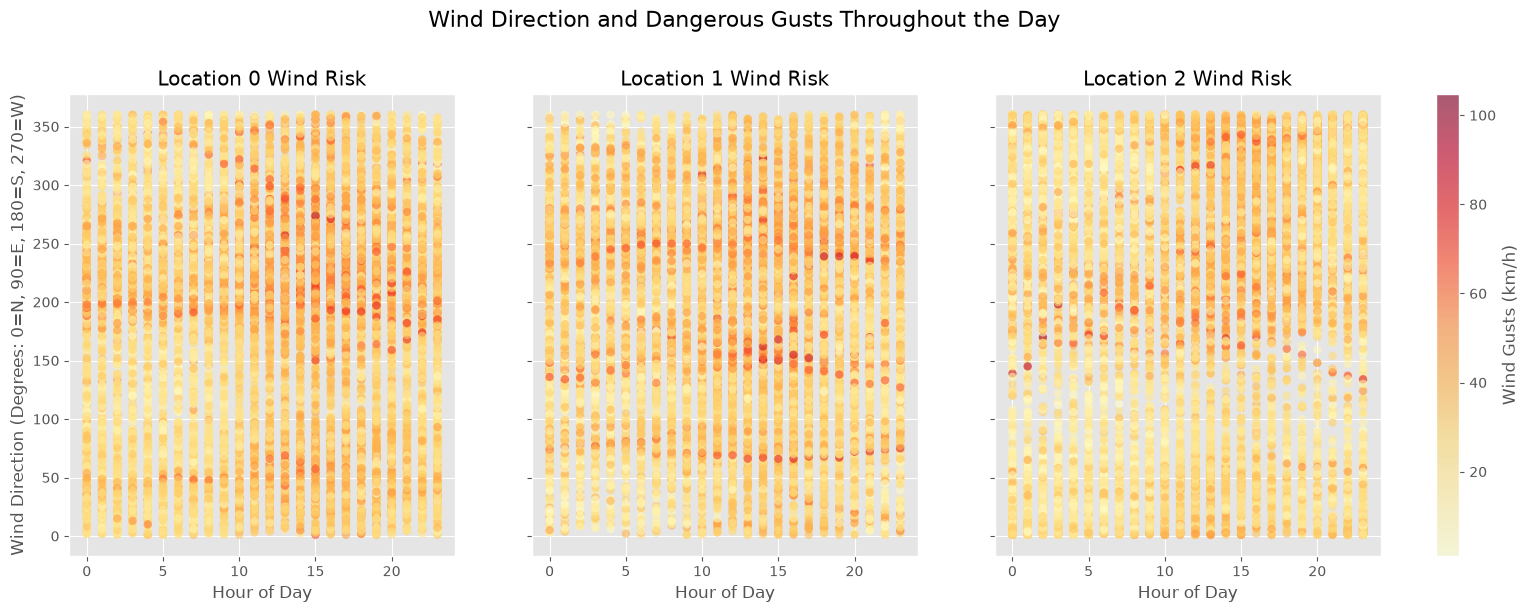

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# 1. FIX: Convert the time column into a real date/time object first!
data['time'] = pd.to_datetime(data['time'])

# 2. Now you can safely extract the hour of the day (0 to 23)
data['Hour'] = data['time'].dt.hour

# 3. Create a figure with a separate subplot for each location side-by-side
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

# Loop through each location and give it its own subplot
for idx, loc_id in enumerate(data['location_id'].unique()):
    loc_df = data[data['location_id'] == loc_id]
    ax = axes[idx]
    
    # Plot Hour vs Wind Direction, colored by Wind Gust strength
    scatter = ax.scatter(
        loc_df['Hour'], 
        loc_df['wind_direction_10m'], 
        c=loc_df['wind_gusts_10m (km/h)'], # Color determined by gusts
        cmap='YlOrRd', # Yellow to Orange to Red color map (Red = Dangerous Gusts)
        alpha=0.6,
        edgecolors='none'
    )
    
    ax.set_title(f'Location {loc_id} Wind Risk')
    ax.set_xlabel('Hour of Day')
    if idx == 0:
        ax.set_ylabel('Wind Direction (Degrees: 0=N, 90=E, 180=S, 270=W)')

# Add a single shared color bar on the right to show gust speeds
# Using ax=axes.tolist() handles multiple subplots perfectly in newer versions
cbar = fig.colorbar(scatter, ax=axes.tolist(), orientation='vertical', fraction=0.02, pad=0.04)
cbar.set_label('Wind Gusts (km/h)')

plt.suptitle('Wind Direction and Dangerous Gusts Throughout the Day', fontsize=16, y=1.02)
plt.show()

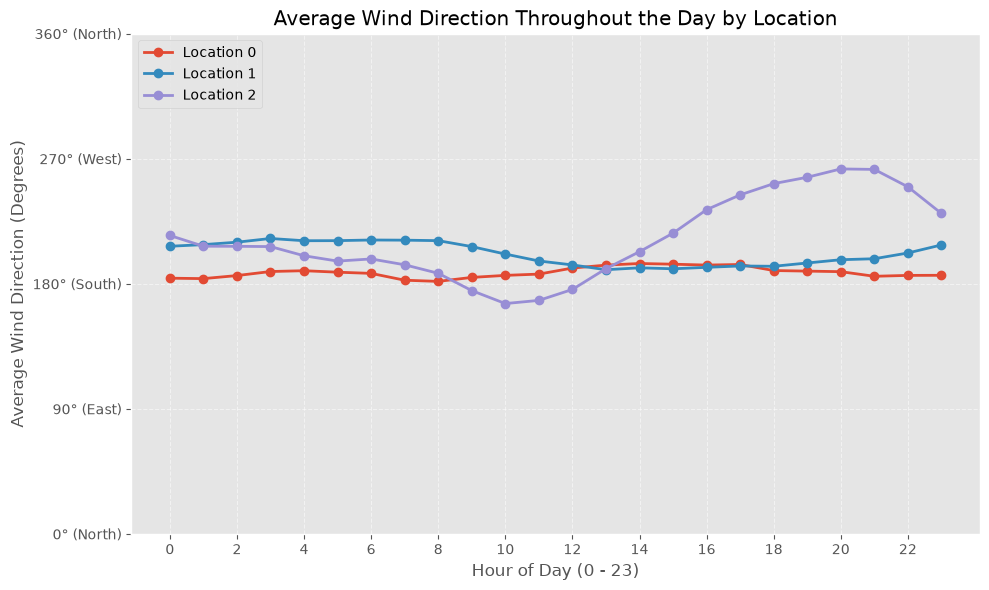

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Ensure time is in the correct format and extract the hour
data['time'] = pd.to_datetime(data['time'])
data['Hour'] = data['time'].dt.hour

# 2. Calculate the average wind direction for each hour for each location
# This groups the data and cleans up the messy scatter dots into averages
hourly_avg_wind = data.groupby(['Hour', 'location_id'])['wind_direction_10m'].mean().unstack()

# 3. Create the single, simple line plot
plt.figure(figsize=(10, 6))

for location in hourly_avg_wind.columns:
    plt.plot(
        hourly_avg_wind.index, 
        hourly_avg_wind[location], 
        marker='o',          # Adds a clean dot at each hour
        linewidth=2, 
        label=f'Location {location}'
    )

# 4. Add clear labels and a grid for easy reading
plt.title('Average Wind Direction Throughout the Day by Location')
plt.xlabel('Hour of Day (0 - 23)')
plt.ylabel('Average Wind Direction (Degrees)')

# Set specific marks for the compass directions on the Y-axis to make it easy to read
plt.yticks([0, 90, 180, 270, 360], ['0° (North)', '90° (East)', '180° (South)', '270° (West)', '360° (North)'])
plt.xticks(range(0, 24, 2)) # Shows hours every 2 hours on the bottom axis

plt.grid(True, linestyle='--', alpha=0.5) # Adds a clean background grid
plt.legend(loc='upper left')
plt.tight_layout()

# Show the simplified graph
plt.show()


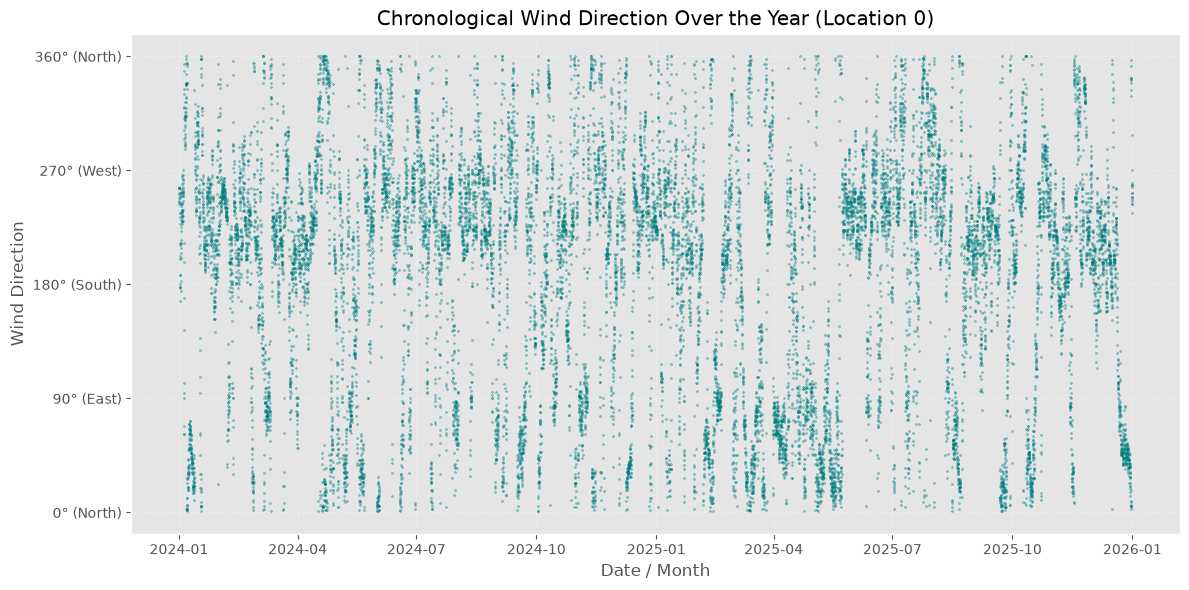

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Ensure time column is a datetime object
data['time'] = pd.to_datetime(data['time'])

# 2. Filter for just Location 0 and sort chronologically
loc0_df = data[data['location_id'] == 0].sort_values('time')

# 3. Plot every single data point over the year
plt.figure(figsize=(12, 6))

# We use a scatter plot with small points (s=2) and make them slightly 
# see-through (alpha=0.4) so you can see where the data points bunch up
plt.scatter(
    loc0_df['time'], 
    loc0_df['wind_direction_10m'], 
    s=2, 
    alpha=0.4, 
    color='teal', 
    label='Wind Data Points'
)

# 4. Add clear labels and title
plt.title('Chronological Wind Direction Over the Year (Location 0)')
plt.xlabel('Date / Month')
plt.ylabel('Wind Direction')

# Set specific marks for compass directions on the Y-axis
plt.yticks([0, 90, 180, 270, 360], ['0° (North)', '90° (East)', '180° (South)', '270° (West)', '360° (North)'])

plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

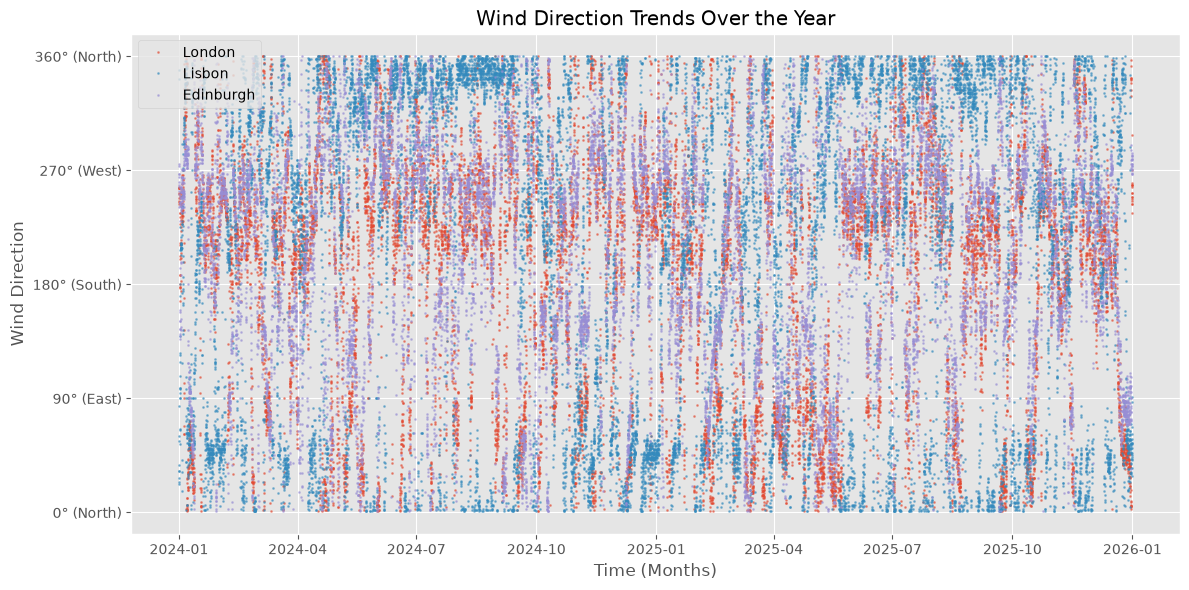

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

# Step 0: Ensure time is in the correct datetime format
data['time'] = pd.to_datetime(data['time'])

# Filter data for each location exactly like your template (sorting by time ensures it flows chronologically)
london = data[data["location_id"] == 0].copy().sort_values('time')
edinburgh = data[data["location_id"] == 1].copy().sort_values('time')
lisbon = data[data["location_id"] == 2].copy().sort_values('time')

# Adjust the figure size to make the seasonal timeline easy to read
plt.figure(figsize=(12, 6))

# Plot wind direction over time for each city using small dots
plt.plot(london["time"], london["wind_direction_10m"], label="London", marker='o', linestyle='none', markersize=1, alpha=0.5)
plt.plot(lisbon["time"], lisbon["wind_direction_10m"], label="Lisbon", marker='o', linestyle='none', markersize=1, alpha=0.5)
plt.plot(edinburgh["time"], edinburgh["wind_direction_10m"], label="Edinburgh", marker='o', linestyle='none', markersize=1, alpha=0.5)

# x-axis label
plt.xlabel('Time (Months)')

# y-axis label
plt.ylabel('Wind Direction')

# Customize the Y-axis marks so your audience instantly sees the compass directions
plt.yticks([0, 90, 180, 270, 360], ['0° (North)', '90° (East)', '180° (South)', '270° (West)', '360° (North)'])

# axis title
plt.title('Wind Direction Trends Over the Year')

plt.legend()
plt.tight_layout()
plt.show()

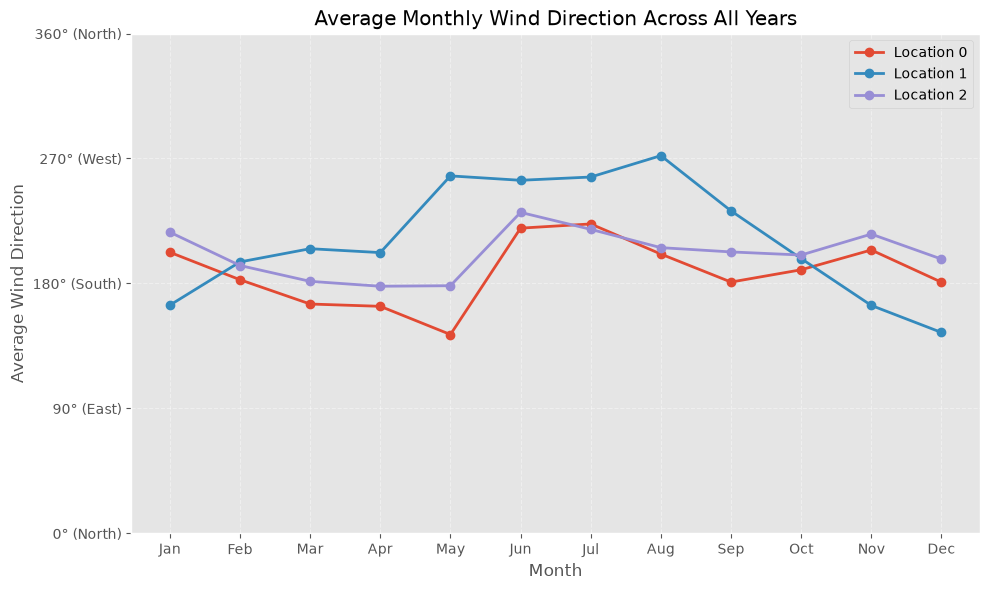

In [24]:
import pandas as pd
import matplotlib.pyplot as plt

# Step 1: Ensure time is in the correct date/time format
data['time'] = pd.to_datetime(data['time'])

# Step 2: Extract the Month number (1 to 12) from the time column
data['Month'] = data['time'].dt.month

# Step 3: Filter the data for each city exactly like your template
london = data[data["location_id"] == 0].copy()
edinburgh = data[data["location_id"] == 1].copy()
lisbon = data[data["location_id"] == 2].copy()

# Step 4: Calculate the average wind direction for each month (combining all days and years)
london_monthly = london.groupby('Month')['wind_direction_10m'].mean().reset_index()
edinburgh_monthly = edinburgh.groupby('Month')['wind_direction_10m'].mean().reset_index()
lisbon_monthly = lisbon.groupby('Month')['wind_direction_10m'].mean().reset_index()

# Step 5: Plot the monthly averages as clear lines with distinct dots
plt.figure(figsize=(10, 6))

plt.plot(london_monthly["Month"], london_monthly["wind_direction_10m"], label="Location 0", marker='o', linewidth=2)
plt.plot(lisbon_monthly["Month"], lisbon_monthly["wind_direction_10m"], label="Location 1", marker='o', linewidth=2)
plt.plot(edinburgh_monthly["Month"], edinburgh_monthly["wind_direction_10m"], label="Location 2", marker='o', linewidth=2)

# Customize the X-axis to show month names instead of just numbers 1-12
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
plt.xticks(range(1, 13), month_names)
plt.xlabel('Month')

# Customize the Y-axis to show clear compass directions
plt.yticks([0, 90, 180, 270, 360], ['0° (North)', '90° (East)', '180° (South)', '270° (West)', '360° (North)'])
plt.ylabel('Average Wind Direction')

# Title and legend
plt.title('Average Monthly Wind Direction Across All Years')
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend()
plt.tight_layout()

plt.show()